In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
import matplotlib.patches as mpl_patches
from scipy.stats import spearmanr

In [3]:
df = pd.read_csv('810_Mg_blues_top3SNPs_wCoordinates_variables.csv')
df

,Accession_ID,Mg_blues,chr5_21392702,chr5_21405867,chr5_282011,Latitude,Longitude,bio1,bio2,bio3,...,K,N,P,ph,sand,silt,srad_mean,ai,GRIDCODE,CLASSLIMIT
0,88,4381.237684,0,0,1,47.4000,0.683333,11.829166,8.825000,37.875538,...,226.204865,1.240112,36.844051,7.186786,51.225914,26.372322,11783.833008,0.6404,38.0,44.8 - 48.2 mg/kg
1,108,4249.456382,0,0,1,48.5167,-4.066670,11.100000,6.416667,37.745098,...,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0,26.9 - 28.9 mg/kg
2,139,4489.038748,0,0,1,48.5167,-4.066670,11.100000,6.416667,37.745098,...,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0,26.9 - 28.9 mg/kg
3,159,4812.735886,0,.,1,47.3500,3.933330,9.325000,7.700000,32.352940,...,143.398697,2.195257,25.737415,5.862647,27.340385,48.445976,11838.916992,0.9524,29.0,23.2 - 25.0 mg/kg
4,265,3798.743649,0,1,1,44.6500,-1.166670,12.962500,9.558333,42.293510,...,237.268997,2.043349,10.124886,5.435710,70.752350,17.501411,12972.333008,0.9147,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,9933,5149.871903,0,0,1,43.7400,3.890000,14.079166,9.141666,35.296009,...,261.559998,1.598961,10.967125,6.837938,23.743881,41.265377,14307.000000,0.4689,44.0,69.5 - 74.8 mg/kg
806,9938,4967.209695,0,0,1,50.6500,2.990000,10.345834,7.675000,34.417042,...,149.106689,1.509961,49.417866,6.471595,28.846939,54.361046,10262.666992,0.8376,36.0,38.7 - 41.7 mg/kg
807,10020,5158.205468,1,0,1,49.1700,16.500000,8.854167,8.458333,29.994089,...,341.494598,1.553450,40.085613,7.549666,16.894424,59.226326,11056.916992,0.5385,53.0,134 - 144 mg/kg
808,10022,4467.362925,0,1,1,48.0333,7.766700,10.783334,8.466667,32.816536,...,208.210236,2.711020,36.571175,6.667569,22.351379,54.793911,11402.500000,0.9392,41.0,55.8 - 60.0 mg/kg


In [4]:
df=df.dropna()
df

,Accession_ID,Mg_blues,chr5_21392702,chr5_21405867,chr5_282011,Latitude,Longitude,bio1,bio2,bio3,...,K,N,P,ph,sand,silt,srad_mean,ai,GRIDCODE,CLASSLIMIT
0,88,4381.237684,0,0,1,47.4000,0.683333,11.829166,8.825000,37.875538,...,226.204865,1.240112,36.844051,7.186786,51.225914,26.372322,11783.833008,0.6404,38.0,44.8 - 48.2 mg/kg
1,108,4249.456382,0,0,1,48.5167,-4.066670,11.100000,6.416667,37.745098,...,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0,26.9 - 28.9 mg/kg
2,139,4489.038748,0,0,1,48.5167,-4.066670,11.100000,6.416667,37.745098,...,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0,26.9 - 28.9 mg/kg
3,159,4812.735886,0,.,1,47.3500,3.933330,9.325000,7.700000,32.352940,...,143.398697,2.195257,25.737415,5.862647,27.340385,48.445976,11838.916992,0.9524,29.0,23.2 - 25.0 mg/kg
5,350,5330.870503,0,0,1,46.6667,4.116670,10.720833,9.175000,35.562016,...,237.669601,1.743629,36.619621,6.276878,31.822845,43.187374,12031.583008,0.7753,36.0,38.7 - 41.7 mg/kg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804,9925,5226.664196,0,0,1,48.9100,4.520000,10.491667,9.450000,36.914062,...,288.782288,1.758133,48.285244,7.874985,22.354774,48.579197,11090.416992,0.7287,32.0,28.9 - 31.1 mg/kg
805,9933,5149.871903,0,0,1,43.7400,3.890000,14.079166,9.141666,35.296009,...,261.559998,1.598961,10.967125,6.837938,23.743881,41.265377,14307.000000,0.4689,44.0,69.5 - 74.8 mg/kg
806,9938,4967.209695,0,0,1,50.6500,2.990000,10.345834,7.675000,34.417042,...,149.106689,1.509961,49.417866,6.471595,28.846939,54.361046,10262.666992,0.8376,36.0,38.7 - 41.7 mg/kg
807,10020,5158.205468,1,0,1,49.1700,16.500000,8.854167,8.458333,29.994089,...,341.494598,1.553450,40.085613,7.549666,16.894424,59.226326,11056.916992,0.5385,53.0,134 - 144 mg/kg


In [9]:
df=df.loc[(df['Latitude']>36.52) & 
             (df['Latitude']<68.80) & 
             (df['Longitude']>-8.54) & 
             (df['Longitude']<38.28)]
df

,Accession_ID,Mg_blues,chr5_21392702,chr5_21405867,chr5_282011,Latitude,Longitude,bio1,bio2,bio3,...,K,N,P,ph,sand,silt,srad_mean,ai,GRIDCODE,CLASSLIMIT
0,88,4381.237684,0,0,1,47.4000,0.683333,11.829166,8.825000,37.875538,...,226.204865,1.240112,36.844051,7.186786,51.225914,26.372322,11783.833008,0.6404,38.0,44.8 - 48.2 mg/kg
1,108,4249.456382,0,0,1,48.5167,-4.066670,11.100000,6.416667,37.745098,...,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0,26.9 - 28.9 mg/kg
2,139,4489.038748,0,0,1,48.5167,-4.066670,11.100000,6.416667,37.745098,...,201.766663,2.772524,44.490234,6.174457,22.396698,60.273209,11146.583008,1.2798,31.0,26.9 - 28.9 mg/kg
3,159,4812.735886,0,.,1,47.3500,3.933330,9.325000,7.700000,32.352940,...,143.398697,2.195257,25.737415,5.862647,27.340385,48.445976,11838.916992,0.9524,29.0,23.2 - 25.0 mg/kg
5,350,5330.870503,0,0,1,46.6667,4.116670,10.720833,9.175000,35.562016,...,237.669601,1.743629,36.619621,6.276878,31.822845,43.187374,12031.583008,0.7753,36.0,38.7 - 41.7 mg/kg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804,9925,5226.664196,0,0,1,48.9100,4.520000,10.491667,9.450000,36.914062,...,288.782288,1.758133,48.285244,7.874985,22.354774,48.579197,11090.416992,0.7287,32.0,28.9 - 31.1 mg/kg
805,9933,5149.871903,0,0,1,43.7400,3.890000,14.079166,9.141666,35.296009,...,261.559998,1.598961,10.967125,6.837938,23.743881,41.265377,14307.000000,0.4689,44.0,69.5 - 74.8 mg/kg
806,9938,4967.209695,0,0,1,50.6500,2.990000,10.345834,7.675000,34.417042,...,149.106689,1.509961,49.417866,6.471595,28.846939,54.361046,10262.666992,0.8376,36.0,38.7 - 41.7 mg/kg
807,10020,5158.205468,1,0,1,49.1700,16.500000,8.854167,8.458333,29.994089,...,341.494598,1.553450,40.085613,7.549666,16.894424,59.226326,11056.916992,0.5385,53.0,134 - 144 mg/kg


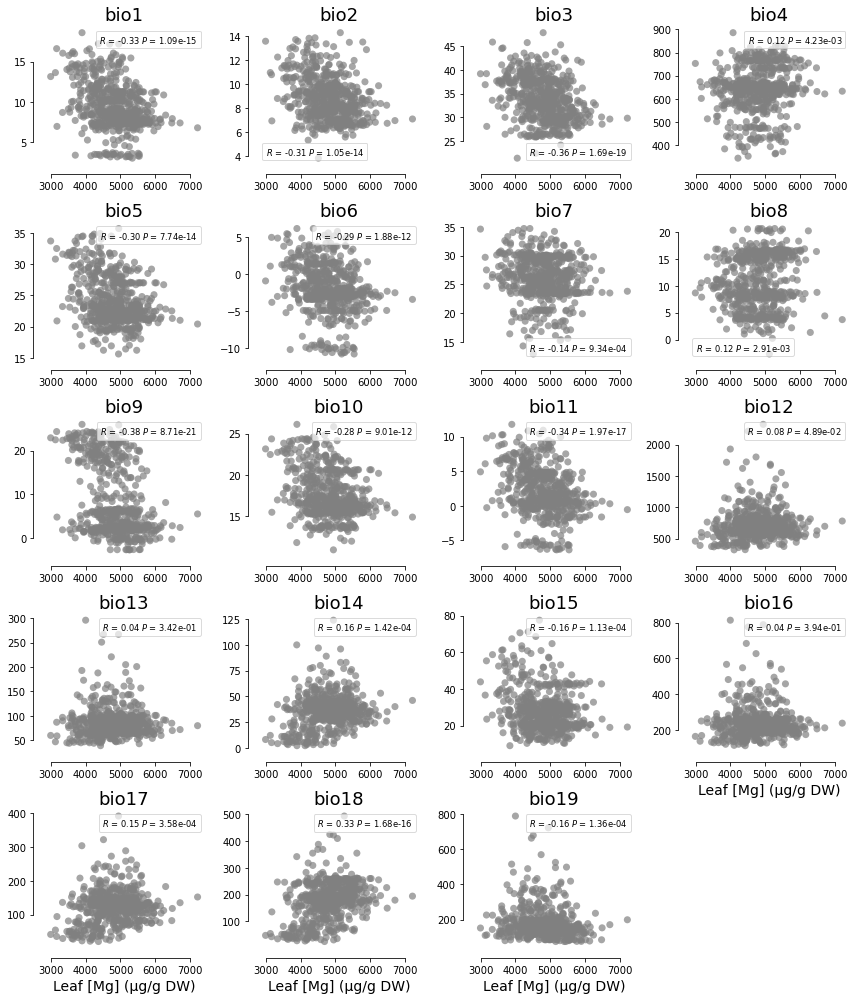

In [10]:
bioclim = ['bio1','bio2','bio3','bio4','bio5',
            'bio6','bio7','bio8','bio9','bio10',
            'bio11','bio12','bio13','bio14','bio15',
            'bio16','bio17','bio18','bio19']
def plots(var,idx1,idx2):
    sns.scatterplot(x='Mg_blues',
                    y=var,
                    color='grey',
                    edgecolor='none',
                    marker='o',
                    s=50,
                    alpha=0.7,
                    data=df,
                    ax=axes[idx1,idx2])

    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 2
    labels = []
    r,p = spearmanr(df[var],df['Mg_blues'])
    labels.append(r"$\itR$ = {:.2f} $P$ = {:.2e}".format(r,p))
    axes[idx1,idx2].legend(handles, labels, loc='best', fontsize='small', 
          fancybox=True, framealpha=0.7, 
          handlelength=0, handletextpad=0)
    axes[idx1,idx2].set_xlabel('')
    axes[idx1,idx2].set_ylabel('')
    axes[idx1,idx2].set_title(var,fontsize=18)
    axes[idx1,idx2].xaxis.set_major_locator(ticker.MultipleLocator(1000))
    
    
fig,axes = plt.subplots(5,4,sharey=False,figsize=(12,14))
a,b=0,0
# for index, value in enumerate(elements):
for index in range(len(bioclim)):
    if index % 4 == 0:
        if index == 0:
            plots(bioclim[index],a,b)
            b+=1
        elif index == 16:
            a+=1
            b=0
            plots(bioclim[index],a,b)
            axes[a,b].set_xlabel('Leaf [Mg] (µg/g DW)',fontsize=14)
            b+=1
        else:
            a+=1
            b=0
            plots(bioclim[index],a,b)
            b+=1
    elif index == 15: 
        plots(bioclim[index],a,b)
        axes[a,b].set_xlabel('Leaf [Mg] (µg/g DW)',fontsize=14)
        b+=1
    elif index > 15:
            if index == 18:
                plots(bioclim[index],a,b)
                axes[a,b].set_xlabel('Leaf [Mg] (µg/g DW)',fontsize=14)
                axes[a,b+1].axis('off')
            else:  
                plots(bioclim[index],a,b)
                axes[a,b].set_xlabel('Leaf [Mg] (µg/g DW)',fontsize=14)
                b+=1
    else:
        plots(bioclim[index],a,b)
        b+=1
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.savefig("FigS2.pdf", format="png",bbox_inches="tight",facecolor='w')